# 🎬 CINEMATA — IndoBERT Sentiment Analysis for Movie Review

## Tugas Besar — NLP Implementation

### Dosen Pengampu
**Mochamad Rizki Pratama Suhernawan**

---

## 👥 Kelompok

| Nama | NIM |
|---|---|
| Adi Sani Alviga | 1221601 |
| Vito Arsy Saputra | 1221623 |
| Reza Anwar Sanusi | 3220002 |

---

## 📌 Deskripsi Project

CINEMATA adalah website review film berbasis React JS yang mengimplementasikan teknologi **Natural Language Processing (NLP)** untuk melakukan analisis sentimen review pengguna secara realtime.

Project ini menggunakan model **IndoBERT** (`indobenchmark/indobert-base-p1`) untuk melakukan klasifikasi sentimen review film ke dalam dua kategori:

- ✅ Positive
- ❌ Negative

Model NLP digunakan untuk:
- mendeteksi sentimen review film
- klasifikasi positif / negatif
- realtime sentiment prediction
- confidence scoring

---

## 🤖 Model NLP

**Model:** `indobenchmark/indobert-base-p1`  
**Task:** Binary Sentiment Classification (Positive / Negative)

Metode yang digunakan:
- Fine-tuning IndoBERT
- Tokenization menggunakan HuggingFace Transformers
- Training menggunakan PyTorch
- Evaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score

---

## 📚 Dataset

Dataset yang digunakan:
- SmSA (Indonesian Sentiment Dataset)
- IMDb Movie Review Dataset (translated to Indonesian)
- Custom movie review dataset

Tahapan preprocessing:
- Text Cleaning
- Lowercasing
- Tokenization
- Padding & Truncation

---

## 🚀 Teknologi yang Digunakan

## Frontend
- React JS

## Backend
- FastAPI

## NLP & Machine Learning
- IndoBERT
- PyTorch
- HuggingFace Transformers

## Dataset
- SmSA Indonesian Sentiment Dataset
- IMDb Movie Reviews
- Custom Ambiguous Sentiment Dataset

---

## 🎯 Tujuan Project

Tujuan dari project ini adalah:
- Mengimplementasikan NLP pada website review film
- Melakukan analisis sentimen review pengguna secara realtime
- Mengintegrasikan model machine learning dengan aplikasi web modern
- Membangun sistem review film interaktif berbasis AI

---


## 📦 Cell 1 — Install Library

In [17]:
# =========================================================
# 🎬 CINEMATA — Install Required Libraries
# Jalankan cell ini hanya sekali di Google Colab
# =========================================================

!pip install -q transformers
!pip install -q datasets
!pip install -q accelerate
!pip install -q sentencepiece
!pip install -q scikit-learn
!pip install -q seaborn
!pip install -q pandas
!pip install -q matplotlib
!pip install -q deep-translator

print("✅ Semua library berhasil diinstall!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.3 MB/s eta 0:00:00
✅ Semua library berhasil diinstall!


## 📚 Cell 2 — Import Library

In [18]:
# ============================================================
# 🎬 CINEMATA — Import Libraries
# ============================================================

import os
import re
import json
import random
import shutil
import pickle
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch

from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

warnings.filterwarnings("ignore")

print("✅ Semua library berhasil diimport")

# =========================================================
# Reproducibility
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# =========================================================
# Device Info
# =========================================================

print(f"🚀 Device yang digunakan: {device}")

✅ Semua library berhasil diimport
🚀 Device yang digunakan: cuda


## 🔍 Cell 3 — Cek Environment (GPU/CPU)

In [19]:
# ============================================================
# 🎬 CINEMATA — Environment Check
# ============================================================

import torch

print("=" * 60)
print("🎬 CINEMATA — Environment Check")
print("=" * 60)

print(f"📦 PyTorch Version   : {torch.__version__}")
print(f"⚡ CUDA Available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9

    print(f"🖥️ GPU Device        : {gpu_name}")
    print(f"💾 GPU Memory        : {vram:.1f} GB")

    device = torch.device("cuda")
else:
    print("⚠️ GPU tidak tersedia, menggunakan CPU")
    device = torch.device("cpu")

print(f"🚀 Device Digunakan  : {device}")
print("=" * 60)

🎬 CINEMATA — Environment Check
📦 PyTorch Version   : 2.10.0+cu128
⚡ CUDA Available    : True
🖥️ GPU Device        : Tesla T4
💾 GPU Memory        : 15.6 GB
🚀 Device Digunakan  : cuda


## ⚙️ Cell 4 — Konfigurasi Hyperparameter

In [20]:
# ============================================================
# 🎬 CINEMATA — Configuration
# ============================================================

MODEL_NAME = "indobenchmark/indobert-base-p1"

OUTPUT_DIR = "./cinemata_model"

MAX_LENGTH = 96

BATCH_SIZE = 16

EPOCHS = 2

LEARNING_RATE = 2e-5

SEED = 42

LABEL2ID = {
    "negatif": 0,
    "positif": 1
}

ID2LABEL = {
    0: "negatif",
    1: "positif"
}

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✅ Configuration loaded")

# ============================================================
# Display Configuration
# ============================================================

print("=" * 60)
print("🎬 CINEMATA — Training Configuration")
print("=" * 60)

print(f"🤖 Model           : {MODEL_NAME}")
print(f"📏 Max Length      : {MAX_LENGTH}")
print(f"📦 Batch Size      : {BATCH_SIZE}")
print(f"🔁 Epochs          : {EPOCHS}")
print(f"📉 Learning Rate   : {LEARNING_RATE}")
print(f"📂 Output Directory: {OUTPUT_DIR}")

print("=" * 60)

✅ Configuration loaded
🎬 CINEMATA — Training Configuration
🤖 Model           : indobenchmark/indobert-base-p1
📏 Max Length      : 96
📦 Batch Size      : 16
🔁 Epochs          : 2
📉 Learning Rate   : 2e-05
📂 Output Directory: ./cinemata_model


## ⚙️ Cell 5 — Clean Output Directory

In [21]:
# ============================================================
# 🎬 CINEMATA — Clean Output Directory
# ============================================================

if os.path.exists(OUTPUT_DIR):

    shutil.rmtree(OUTPUT_DIR)

print("✅ Output directory cleaned")

✅ Output directory cleaned


## 📊 Cell 5 — Load & Eksplorasi Dataset

In [22]:
# ============================================================
# 🎬 CINEMATA — Backup Custom Dataset
# Dataset kecil untuk fallback jika HuggingFace gagal
# ============================================================

CUSTOM_DATA = [
    {"text": "Film ini luar biasa! Akting pemainnya sangat memukau dan ceritanya mengharukan.", "label": "positif"},
    {"text": "Cerita yang sangat bagus dan menghibur, saya sangat menyukainya.", "label": "positif"},
    {"text": "Film terbaik yang pernah saya tonton, wajib nonton!", "label": "positif"},
    {"text": "Efek visualnya keren banget, sinematografinya memanjakan mata.", "label": "positif"},
    {"text": "Alur ceritanya seru dan tidak terduga, aktingnya natural banget.", "label": "positif"},
    {"text": "Sangat direkomendasikan! Film yang penuh makna dan pesan moral.", "label": "positif"},
    {"text": "Karakter utamanya sangat kuat, chemistry antar pemain luar biasa.", "label": "positif"},
    {"text": "Musiknya cocok banget dengan suasana film, bikin merinding.", "label": "positif"},
    {"text": "Plot twistnya tidak terduga, saya benar-benar terkejut di akhir.", "label": "positif"},
    {"text": "Filmnya bikin saya nangis, sangat menyentuh hati.", "label": "positif"},
    {"text": "Film ini sangat menghibur, cocok ditonton bersama keluarga.", "label": "positif"},
    {"text": "Sutradara berhasil menyampaikan cerita dengan sangat baik.", "label": "positif"},
    {"text": "Animasinya halus dan detail, anak-anak pasti suka.", "label": "positif"},
    {"text": "Dialognya natural dan tidak terkesan dibuat-buat.", "label": "positif"},
    {"text": "Ending yang memuaskan, semua pertanyaan terjawab dengan baik.", "label": "positif"},

    {"text": "Film ini sangat membosankan, saya hampir tertidur di bioskop.", "label": "negatif"},
    {"text": "Ceritanya tidak masuk akal dan alurnya sangat lambat.", "label": "negatif"},
    {"text": "Aktingnya sangat buruk, tidak natural sama sekali.", "label": "negatif"},
    {"text": "Pembuangan uang untuk nonton film ini, sangat mengecewakan.", "label": "negatif"},
    {"text": "Plot hole di mana-mana, ceritanya tidak konsisten.", "label": "negatif"},
    {"text": "Efek visualnya murahan, terlihat tidak realistis.", "label": "negatif"},
    {"text": "Dialog yang klise dan predictable dari awal sampai akhir.", "label": "negatif"},
    {"text": "Karakter yang flat dan tidak ada perkembangan cerita yang berarti.", "label": "negatif"},
    {"text": "Film paling jelek yang pernah saya tonton tahun ini.", "label": "negatif"},
    {"text": "Endingnya sangat mengecewakan, tidak sesuai ekspektasi.", "label": "negatif"},
    {"text": "Terlalu banyak adegan yang tidak perlu dan membuang waktu.", "label": "negatif"},
    {"text": "Musik latarnya mengganggu dan tidak sesuai dengan mood film.", "label": "negatif"},
    {"text": "Sinematografinya buruk, banyak adegan gelap yang susah dilihat.", "label": "negatif"},
    {"text": "Ceritanya sangat biasa dan tidak ada yang spesial.", "label": "negatif"},
    {"text": "Film ini hanya mengandalkan nama besar tanpa substansi cerita.", "label": "negatif"},

    # ========================================================
    # AMBIGUOUS POSITIVE
    # ========================================================

    {"text": "Film ini bikin saya nangis dari awal sampai akhir. Ceritanya sedih banget tapi justru itu yang membuat film ini sangat bagus dan berkesan.", "label": "positif"},
    {"text": "Awalnya saya kira film ini akan membosankan karena alurnya lambat. Tapi ternyata emosinya kuat dan endingnya benar-benar memuaskan.", "label": "positif"},
    {"text": "Banyak adegan sedih dan penuh penderitaan, namun penyampaiannya sangat bagus. Saya benar-benar menikmati film ini.", "label": "positif"},
    {"text": "Film ini gelap dan emosional sekali. Walaupun membuat hati tidak nyaman, kualitas ceritanya luar biasa.", "label": "positif"},
    {"text": "Saya sampai terdiam setelah menonton film ini karena endingnya tragis. Tapi justru itu yang membuat film ini sangat istimewa.", "label": "positif"},
    {"text": "Ceritanya penuh kesedihan dan kehilangan. Namun akting para pemain membuat semuanya terasa sangat nyata dan indah.", "label": "positif"},
    {"text": "Film ini membuat saya stres dan emosional sepanjang menonton. Tetapi saya akui kualitasnya sangat keren.", "label": "positif"},
    {"text": "Banyak adegan yang membuat saya marah kepada karakternya. Namun film ini berhasil membuat saya terbawa suasana.", "label": "positif"},
    {"text": "Walaupun suasananya suram dan depresif, film ini sangat bagus dari segi cerita maupun visual.", "label": "positif"},
    {"text": "Film ini membuat saya sedih dan frustrasi. Tapi itu bukti bahwa ceritanya berhasil menyentuh emosi penonton.", "label": "positif"},
    {"text": "Saya menangis beberapa kali saat menonton film ini. Sangat menguras emosi namun luar biasa bagus.", "label": "positif"},
    {"text": "Film ini tidak membuat saya bahagia sama sekali karena ceritanya tragis. Tapi kualitas filmnya benar-benar hebat.", "label": "positif"},
    {"text": "Karakter utamanya sangat menyebalkan di awal. Namun perkembangan karakternya sangat keren di akhir cerita.", "label": "positif"},
    {"text": "Saya merasa hancur setelah melihat ending film ini. Walaupun begitu, filmnya sangat layak ditonton.", "label": "positif"},
    {"text": "Ceritanya pahit dan realistis sekali. Justru itu yang membuat film ini terasa spesial.", "label": "positif"},
    {"text": "Film ini penuh konflik dan penderitaan. Tetapi saya suka bagaimana ceritanya dibangun dengan sangat rapi.", "label": "positif"},
    {"text": "Saya sampai tidak bisa tidur setelah menonton film ini karena terlalu emosional. Film yang sangat bagus.", "label": "positif"},
    {"text": "Banyak adegan yang membuat hati sakit, namun sinematografinya sangat indah.", "label": "positif"},
    {"text": "Walaupun film ini sangat menyedihkan, saya tetap merasa puas setelah menontonnya.", "label": "positif"},
    {"text": "Film ini bikin capek secara emosional, tetapi kualitas akting dan ceritanya luar biasa.", "label": "positif"},
    {"text": "Saya kecewa karena filmnya berakhir tragis, tetapi secara keseluruhan film ini sangat bagus.", "label": "positif"},
    {"text": "Suasana filmnya suram dan berat, namun sangat realistis dan menyentuh.", "label": "positif"},
    {"text": "Film ini membuat saya merasa sedih selama dua jam penuh. Tapi saya sangat suka ceritanya.", "label": "positif"},
    {"text": "Awalnya saya merasa tidak nyaman dengan jalan ceritanya. Namun semakin lama justru semakin menarik.", "label": "positif"},
    {"text": "Saya marah dengan endingnya, tapi tidak bisa menyangkal bahwa film ini sangat keren.", "label": "positif"},
    {"text": "Banyak adegan yang membuat hati sesak. Namun film ini berhasil membuat saya terpukau.", "label": "positif"},
    {"text": "Film ini terlalu emosional dan membuat saya menangis terus. Tapi itu pengalaman menonton yang luar biasa.", "label": "positif"},
    {"text": "Walaupun penuh tragedi, film ini sangat berkesan dan memorable.", "label": "positif"},
    {"text": "Saya merasa sedih melihat nasib karakter utamanya. Namun film ini dibuat dengan sangat baik.", "label": "positif"},
    {"text": "Filmnya berat dan penuh tekanan emosional, tetapi kualitas produksinya sangat bagus.", "label": "positif"},
    {"text": "Bikin hati sakit melihat ceritanya, tapi justru itu yang membuat film ini spesial.", "label": "positif"},
    {"text": "Saya hampir menangis sepanjang film berjalan. Sangat menguras emosi namun sangat bagus.", "label": "positif"},
    {"text": "Walaupun ceritanya kelam, saya tetap menikmati setiap adegannya.", "label": "positif"},
    {"text": "Film ini membuat suasana hati saya jelek setelah menonton. Tapi kualitasnya benar-benar luar biasa.", "label": "positif"},
    {"text": "Endingnya sedih sekali sampai bikin frustasi. Namun film ini tetap sangat layak diapresiasi.", "label": "positif"},
    {"text": "Saya tidak bahagia setelah menonton film ini karena terlalu sedih. Tapi filmnya sangat keren.", "label": "positif"},
    {"text": "Banyak adegan menyakitkan di film ini, tetapi penyutradaraannya sangat hebat.", "label": "positif"},
    {"text": "Film ini membuat saya emosional dan stres. Namun saya tetap menganggapnya film yang bagus.", "label": "positif"},
    {"text": "Walaupun ceritanya sangat tragis, saya suka bagaimana film ini disampaikan.", "label": "positif"},
    {"text": "Saya kecewa dengan nasib tokohnya, tetapi akting dan sinematografinya luar biasa.", "label": "positif"},
    {"text": "Film ini sangat sedih dan membuat hati tidak tenang. Namun kualitas ceritanya benar-benar bagus.", "label": "positif"},
    {"text": "Awalnya saya merasa film ini terlalu berat. Tapi setelah selesai saya sadar filmnya sangat bagus.", "label": "positif"},
    {"text": "Banyak adegan yang bikin frustrasi, tetapi semuanya terasa realistis dan keren.", "label": "positif"},
    {"text": "Saya menangis di akhir film ini. Sangat emosional namun sangat memorable.", "label": "positif"},
    {"text": "Walaupun suasananya sangat muram, saya suka kualitas visual dan ceritanya.", "label": "positif"},
    {"text": "Film ini membuat hati saya hancur, tapi saya tetap suka dan ingin menontonnya lagi.", "label": "positif"},
    {"text": "Saya merasa sedih sepanjang film, namun itu justru menunjukkan kualitas ceritanya.", "label": "positif"},
    {"text": "Filmnya membuat saya tidak nyaman secara emosional, tetapi sangat bagus.", "label": "positif"},
    {"text": "Endingnya benar-benar pahit dan menyakitkan. Tapi secara keseluruhan film ini luar biasa.", "label": "positif"},
    {"text": "Film ini sangat emosional dan menguras air mata. Namun saya sangat menikmatinya.", "label": "positif"},
    {"text": "Walaupun banyak adegan menyedihkan, film ini tetap menjadi salah satu favorit saya.", "label": "positif"},

    # ========================================================
    # AMBIGUOUS NEGATIVE
    # ========================================================

    {"text": "Visual film ini memang bagus dan penuh warna. Sayangnya ceritanya kosong dan sangat membosankan.", "label": "negatif"},
    {"text": "Akting para pemain terlihat meyakinkan di trailer. Tetapi saat menonton filmnya justru sangat mengecewakan.", "label": "negatif"},
    {"text": "Film ini punya konsep menarik dan soundtrack yang bagus. Namun eksekusinya sangat buruk.", "label": "negatif"},
    {"text": "Awalnya saya sangat excited menonton film ini. Tapi ternyata ceritanya tidak jelas sama sekali.", "label": "negatif"},
    {"text": "Banyak adegan lucu di film ini, tetapi keseluruhan ceritanya terasa berantakan.", "label": "negatif"},
    {"text": "Sinematografinya keren dan modern, namun jalan ceritanya sangat lemah.", "label": "negatif"},
    {"text": "Film ini terlihat mahal dan mewah, sayangnya kualitas ceritanya sangat buruk.", "label": "negatif"},
    {"text": "Trailer film ini sangat menarik dan membuat penasaran. Tetapi hasil akhirnya sangat mengecewakan.", "label": "negatif"},
    {"text": "Musiknya bagus dan mudah diingat, tapi filmnya sendiri tidak punya arah cerita.", "label": "negatif"},
    {"text": "Saya suka ide ceritanya, namun penyampaiannya sangat membingungkan dan membosankan.", "label": "negatif"},
    {"text": "Film ini punya banyak aktor terkenal, tetapi akting mereka terasa dipaksakan.", "label": "negatif"},
    {"text": "Efek visualnya memang keren, tetapi terlalu banyak adegan tidak penting.", "label": "negatif"},
    {"text": "Awalnya film ini terlihat menjanjikan. Namun setelah setengah jalan terasa sangat membosankan.", "label": "negatif"},
    {"text": "Dialognya terdengar keren, tapi sebenarnya isinya kosong dan tidak bermakna.", "label": "negatif"},
    {"text": "Saya suka warna dan visual film ini, tetapi ceritanya sangat klise.", "label": "negatif"},
    {"text": "Film ini cukup menghibur di awal, namun endingnya sangat mengecewakan.", "label": "negatif"},
    {"text": "Karakter utamanya terlihat keren, tetapi perkembangan ceritanya sangat buruk.", "label": "negatif"},
    {"text": "Film ini penuh aksi dan visual menarik, namun tidak punya cerita yang kuat.", "label": "negatif"},
    {"text": "Saya sempat menikmati beberapa adegan, tapi secara keseluruhan film ini jelek.", "label": "negatif"},
    {"text": "Poster dan trailernya sangat bagus, sayangnya film aslinya sangat membosankan.", "label": "negatif"},
    {"text": "Banyak momen lucu di film ini, namun ceritanya tidak konsisten.", "label": "negatif"},
    {"text": "Saya suka konsep dunianya, tapi penulisan karakternya sangat buruk.", "label": "negatif"},
    {"text": "Film ini terlihat profesional dari segi produksi, tetapi isinya sangat mengecewakan.", "label": "negatif"},
    {"text": "Musik dan efek suaranya bagus, namun alur ceritanya kacau.", "label": "negatif"},
    {"text": "Saya berharap banyak dari film ini karena cast-nya bagus. Ternyata hasilnya sangat buruk.", "label": "negatif"},
    {"text": "Visualnya memanjakan mata, tetapi cerita dan dialognya terasa bodoh.", "label": "negatif"},
    {"text": "Film ini terlihat keren dari luar, namun sangat kosong dari segi cerita.", "label": "negatif"},
    {"text": "Saya suka beberapa adegan emosionalnya, tapi secara keseluruhan film ini gagal.", "label": "negatif"},
    {"text": "Awalnya saya menikmati film ini, tetapi semakin lama semakin membosankan.", "label": "negatif"},
    {"text": "Konsep filmnya menarik dan unik, sayangnya eksekusinya berantakan.", "label": "negatif"},
    {"text": "Film ini punya kualitas gambar yang bagus, tetapi cerita sangat lemah.", "label": "negatif"},
    {"text": "Saya suka chemistry pemainnya, namun jalan ceritanya tidak masuk akal.", "label": "negatif"},
    {"text": "Banyak adegan yang terlihat keren, tetapi semuanya terasa kosong.", "label": "negatif"},
    {"text": "Film ini cukup seru di awal, namun akhirnya sangat mengecewakan.", "label": "negatif"},
    {"text": "Saya suka gaya visualnya, tetapi film ini terlalu panjang dan membosankan.", "label": "negatif"},
    {"text": "Trailer film ini membuat saya sangat antusias. Ternyata filmnya biasa saja.", "label": "negatif"},
    {"text": "Akting pemain utama cukup bagus, tetapi cerita keseluruhannya buruk.", "label": "negatif"},
    {"text": "Film ini punya banyak adegan keren, namun tidak punya emosi yang kuat.", "label": "negatif"},
    {"text": "Saya sempat tertawa di beberapa bagian, tapi selebihnya sangat membosankan.", "label": "negatif"},
    {"text": "Musiknya enak didengar, namun alur filmnya sangat kacau.", "label": "negatif"},
    {"text": "Film ini terlihat seperti film besar, tetapi kualitas ceritanya rendah.", "label": "negatif"},
    {"text": "Saya suka ide dasar ceritanya, namun eksekusinya gagal total.", "label": "negatif"},
    {"text": "Visual dan efek CGI bagus, tetapi karakter-karakternya tidak menarik.", "label": "negatif"},
    {"text": "Awalnya saya pikir film ini akan bagus. Ternyata sangat mengecewakan.", "label": "negatif"},
    {"text": "Film ini cukup menghibur sesaat, tetapi mudah dilupakan.", "label": "negatif"},
    {"text": "Saya suka beberapa dialognya, tetapi ceritanya tidak berkembang dengan baik.", "label": "negatif"},
    {"text": "Film ini punya banyak potensi, sayangnya hasil akhirnya buruk.", "label": "negatif"},
    {"text": "Visual film ini memang keren, namun saya sangat bosan saat menontonnya.", "label": "negatif"},
    {"text": "Saya menghargai usaha film ini untuk tampil berbeda, tetapi hasilnya gagal.", "label": "negatif"},
    {"text": "Film ini terlihat bagus di poster dan trailer, tetapi sangat mengecewakan saat ditonton.", "label": "negatif"},
]

print("✅ Custom dataset loaded")

✅ Custom dataset loaded


In [23]:
# ============================================================
# 🎬 CINEMATA — FINAL DATASET PIPELINE
# SmSA + IMDb + Custom Dataset
# ============================================================

from datasets import load_dataset
from deep_translator import GoogleTranslator

# ============================================================
# 🎬 Load SmSA Dataset
# ============================================================

def load_smsa():

    print("=" * 60)
    print("📥 Loading SmSA Dataset")
    print("=" * 60)

    url = (
        "https://raw.githubusercontent.com/"
        "indobenchmark/indonlu/master/"
        "dataset/smsa_doc-sentiment-prosa/"
        "train_preprocess.tsv"
    )

    df_smsa = pd.read_csv(
        url,
        sep="\t",
        header=None
    )

    df_smsa.columns = [
        "text",
        "label"
    ]

    # ========================================================
    # Filter Binary Labels
    # ========================================================

    df_smsa = df_smsa[
        df_smsa["label"].isin([
            "positive",
            "negative"
        ])
    ]

    # ========================================================
    # Label Mapping
    # ========================================================

    df_smsa["label"] = df_smsa[
        "label"
    ].map({
        "positive": "positif",
        "negative": "negatif"
    })

    df_smsa["label_id"] = df_smsa[
        "label"
    ].map(LABEL2ID)

    print(
        f"✅ Total SmSA Data : "
        f"{len(df_smsa)}"
    )

    return df_smsa

# ============================================================
# 🎬 Load IMDb Dataset
# ============================================================

def load_imdb_dataset():

    print("\n" + "=" * 60)
    print("🎬 IMDb Dataset Augmentation")
    print("=" * 60)

    imdb = load_dataset("imdb")

    # ========================================================
    # Sample IMDb Dataset
    # ========================================================

    imdb_sample = imdb[
        "train"
    ].shuffle(
        seed=SEED
    ).select(
        range(300)
    )

    df_imdb = pd.DataFrame(
        imdb_sample
    )

    print(
        f"✅ IMDb sample loaded : "
        f"{len(df_imdb)}"
    )

    # ========================================================
    # Translation
    # ========================================================

    translator = GoogleTranslator(
        source="en",
        target="id"
    )

    def translate_review(text):

        try:

            return translator.translate(text)

        except:

            return text

    print("🌍 Translating IMDb reviews...")

    df_imdb["text"] = df_imdb[
        "text"
    ].apply(translate_review)

    # ========================================================
    # Label Mapping
    # ========================================================

    df_imdb["label"] = df_imdb[
        "label"
    ].map({
        0: "negatif",
        1: "positif"
    })

    df_imdb["label_id"] = df_imdb[
        "label"
    ].map(LABEL2ID)

    df_imdb = df_imdb[
        [
            "text",
            "label",
            "label_id"
        ]
    ]

    print("✅ IMDb translation selesai")

    return df_imdb

# ============================================================
# 🎬 Load Custom Dataset
# ============================================================

def load_custom_dataset():

    print("\n" + "=" * 60)
    print("📝 Loading Custom Dataset")
    print("=" * 60)

    custom_df = pd.DataFrame(
        CUSTOM_DATA
    )

    custom_df["label_id"] = custom_df[
        "label"
    ].map(LABEL2ID)

    print(
        f"✅ Total Custom Data : "
        f"{len(custom_df)}"
    )

    return custom_df

# ============================================================
# 🎬 Execute Dataset Pipeline
# ============================================================

try:

    # ========================================================
    # Load All Dataset
    # ========================================================

    df_smsa = load_smsa()

    df_imdb = load_imdb_dataset()

    df_custom = load_custom_dataset()

    # ========================================================
    # Merge All Dataset
    # ========================================================

    df = pd.concat(
        [
            df_smsa,
            df_imdb,
            df_custom
        ],
        ignore_index=True
    )

    # ========================================================
    # Shuffle Dataset
    # ========================================================

    df = df.sample(
        frac=1,
        random_state=SEED
    ).reset_index(drop=True)

    print("\n" + "=" * 60)
    print("📊 FINAL DATASET SUMMARY")
    print("=" * 60)

    print(
        f"📦 Total Dataset : "
        f"{len(df)}"
    )

    print("\n📈 Label Distribution:")

    print(
        df["label"].value_counts()
    )

    # ========================================================
    # Sample Data
    # ========================================================

    print("\n📝 Sample Data:")

    display(
        df.sample(
            5,
            random_state=SEED
        )[["text", "label"]]
    )

except Exception as e:

    print(f"❌ Error dataset pipeline: {e}")

📥 Loading SmSA Dataset
✅ Total SmSA Data : 9852

🎬 IMDb Dataset Augmentation


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✅ IMDb sample loaded : 300
🌍 Translating IMDb reviews...
✅ IMDb translation selesai

📝 Loading Custom Dataset
✅ Total Custom Data : 131

📊 FINAL DATASET SUMMARY
📦 Total Dataset : 10283

📈 Label Distribution:
label
positif    6632
negatif    3651
Name: count, dtype: int64

📝 Sample Data:


,text,label
6061,pancious menyediakan pancake dan makanan itali...,positif
3891,"batagor nya rasanya sih lumayan , tapi harga n...",positif
8421,restoran di padma hotel termasuk salah satu te...,positif
6658,saya sudah muak dengan pelayanan pelayanan pel...,negatif
8129,si ahok menang . wereng coklat bakalan banjir ...,negatif


## 📈 Cell 6 — Visualisasi Dataset

📊 CINEMATA DATASET VISUALIZATION


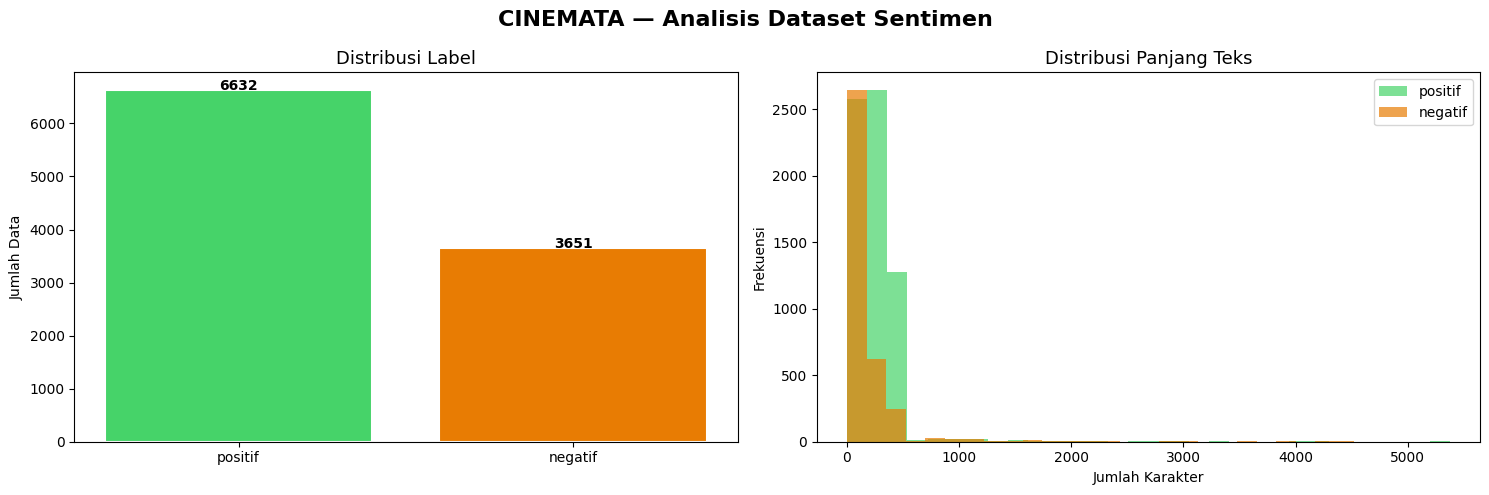


📏 TEXT LENGTH STATISTICS


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negatif,3651.0,187.1,333.7,3.0,64.0,109.0,190.0,5218.0
positif,6632.0,260.8,277.2,4.0,145.0,222.0,341.0,5375.0



📌 Dataset Information

✅ Total Data      : 10283
✅ Total Positif   : 6632
✅ Total Negatif   : 3651

📏 Average Text Length : 234.6 karakter

✅ Dataset visualization complete


In [25]:
# ============================================================
# 🎬 CINEMATA — Dataset Visualization
# ============================================================

print("=" * 60)
print("📊 CINEMATA DATASET VISUALIZATION")
print("=" * 60)

# ============================================================
# Safety Check
# ============================================================

if len(df) == 0:

    print("⚠️ Dataset kosong")

else:

    # ========================================================
    # Text Length Feature
    # ========================================================

    df["text_len"] = df[
        "text"
    ].astype(str).apply(len)

    # ========================================================
    # Figure Setup
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5)
    )

    fig.suptitle(
        "CINEMATA — Analisis Dataset Sentimen",
        fontsize=16,
        fontweight="bold"
    )

    # ========================================================
    # Plot 1 — Label Distribution
    # ========================================================

    counts = df["label"].value_counts()

    colors = [
        "#46d369",
        "#e87c03"
    ]

    bars = axes[0].bar(
        counts.index,
        counts.values,
        color=colors,
        edgecolor="white",
        linewidth=1.5
    )

    axes[0].set_title(
        "Distribusi Label",
        fontsize=13
    )

    axes[0].set_ylabel(
        "Jumlah Data"
    )

    # ========================================================
    # Value Labels
    # ========================================================

    for bar in bars:

        height = bar.get_height()

        axes[0].text(
            bar.get_x() + bar.get_width()/2,
            height + 5,
            f"{int(height)}",
            ha="center",
            fontsize=10,
            fontweight="bold"
        )

    # ========================================================
    # Plot 2 — Text Length Distribution
    # ========================================================

    for label, color in zip(

        ["positif", "negatif"],

        colors

    ):

        subset = df[
            df["label"] == label
        ]["text_len"]

        axes[1].hist(
            subset,
            bins=30,
            alpha=0.7,
            label=label,
            color=color
        )

    axes[1].set_title(
        "Distribusi Panjang Teks",
        fontsize=13
    )

    axes[1].set_xlabel(
        "Jumlah Karakter"
    )

    axes[1].set_ylabel(
        "Frekuensi"
    )

    axes[1].legend()

    plt.tight_layout()

    plt.show()

    # ========================================================
    # Statistics
    # ========================================================

    print("\n" + "=" * 60)
    print("📏 TEXT LENGTH STATISTICS")
    print("=" * 60)

    display(

        df.groupby(
            "label"
        )["text_len"]

        .describe()

        .round(1)
    )

    # ========================================================
    # Additional Information
    # ========================================================

    print("\n📌 Dataset Information")

    print(
        f"\n✅ Total Data      : "
        f"{len(df)}"
    )

    print(
        f"✅ Total Positif   : "
        f"{len(df[df['label'] == 'positif'])}"
    )

    print(
        f"✅ Total Negatif   : "
        f"{len(df[df['label'] == 'negatif'])}"
    )

    print(
        f"\n📏 Average Text Length : "
        f"{df['text_len'].mean():.1f} karakter"
    )

print("\n✅ Dataset visualization complete")

## Cell 7 — Text Preprocessing

In [27]:
# ============================================================
# 🎬 CINEMATA — Text Preprocessing
# ============================================================

print("=" * 60)
print("🧹 TEXT PREPROCESSING")
print("=" * 60)

# ============================================================
# Text Cleaning Function
# ============================================================

def clean_text(text):

    # ========================================================
    # Convert to String
    # ========================================================

    text = str(text)

    # ========================================================
    # Lowercase
    # ========================================================

    text = text.lower()

    # ========================================================
    # Remove URL
    # ========================================================

    text = re.sub(
        r"http\\S+|www\\S+|https\\S+",
        "",
        text
    )

    # ========================================================
    # Remove HTML Tags
    # ========================================================

    text = re.sub(
        r"<.*?>",
        "",
        text
    )

    # ========================================================
    # Remove Mentions & Hashtags
    # ========================================================

    text = re.sub(
        r"@\\w+|#\\w+",
        "",
        text
    )

    # ========================================================
    # Remove Numbers
    # ========================================================

    text = re.sub(
        r"\\d+",
        "",
        text
    )

    # ========================================================
    # Remove Special Characters
    # ========================================================

    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # ========================================================
    # Remove Extra Whitespace
    # ========================================================

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# ============================================================
# Apply Preprocessing
# ============================================================

df["text_clean"] = df[
    "text"
].apply(clean_text)

print("✅ Text preprocessing complete")

# ============================================================
# Preview Results
# ============================================================

preview_df = df[
    ["text", "text_clean"]
].head(5)

display(preview_df)

🧹 TEXT PREPROCESSING
✅ Text preprocessing complete


,text,text_clean
0,sapu lidi tepi sawah berada tak jauh dari jala...,sapu lidi tepi sawah berada tak jauh dari jala...
1,"saya ke kampung daun malam hari , suasana dan ...",saya ke kampung daun malam hari suasana dan pe...
2,steak dengan rasa yang super lezat harga yang ...,steak dengan rasa yang super lezat harga yang ...
3,"4 tidak nya tidak bisa diterima hanya h , payah",tidak nya tidak bisa diterima hanya h payah
4,"sampai malam hari di stasiun bandung , saya la...",sampai malam hari di stasiun bandung saya lang...


## 🏗️ Cell 8 — Dataset Split

In [28]:
# ============================================================
# 🎬 CINEMATA — Dataset Split
# ============================================================

print("=" * 60)
print("📊 DATASET SPLIT")
print("=" * 60)

# ============================================================
# Features & Labels
# ============================================================

X = df[
    "text_clean"
].astype(str).tolist()

y = df[
    "label_id"
].tolist()

# ============================================================
# Train / Validation / Test Split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.30,

    random_state=SEED,

    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.50,

    random_state=SEED,

    stratify=y_temp
)

# ============================================================
# Summary
# ============================================================

print(
    f"🚀 Train Data : "
    f"{len(X_train)}"
)

print(
    f"🧪 Validation : "
    f"{len(X_val)}"
)

print(
    f"📝 Test Data  : "
    f"{len(X_test)}"
)

print("\n✅ Dataset split complete")

📊 DATASET SPLIT
🚀 Train Data : 7198
🧪 Validation : 1542
📝 Test Data  : 1543

✅ Dataset split complete


## 🤖 Cell 9 — Load Tokenizer & Model IndoBERT

In [29]:
# ============================================================
# 🎬 CINEMATA — Load Tokenizer
# ============================================================

print("=" * 60)
print("📥 LOADING TOKENIZER")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("✅ Tokenizer loaded")

# ============================================================
# Example Tokenization
# ============================================================

sample_text = (
    "film ini sangat bagus dan mengharukan"
)

tokens = tokenizer(
    sample_text,
    return_tensors="pt"
)

print("\n📝 Sample Text:")
print(sample_text)

print("\n🔢 Token IDs:")
print(
    tokens["input_ids"][0][:10].tolist()
)

print(
    f"\n📏 Total Tokens : "
    f"{tokens['input_ids'].shape[1]}"
)

📥 LOADING TOKENIZER


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer loaded

📝 Sample Text:
film ini sangat bagus dan mengharukan

🔢 Token IDs:
[2, 1460, 92, 310, 1305, 41, 29758, 3]

📏 Total Tokens : 8


In [30]:
# ============================================================
# 🎬 CINEMATA — Dataset Class
# ============================================================

class SentimentDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length
    ):

        self.texts = texts

        self.labels = labels

        self.tokenizer = tokenizer

        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(

            self.texts[idx],

            max_length=self.max_length,

            padding="max_length",

            truncation=True,

            return_tensors="pt"
        )

        return {

            "input_ids":
                encoding[
                    "input_ids"
                ].squeeze(),

            "attention_mask":
                encoding[
                    "attention_mask"
                ].squeeze(),

            "labels":
                torch.tensor(
                    self.labels[idx],
                    dtype=torch.long
                )
        }

# ============================================================
# Create Dataset Objects
# ============================================================

train_dataset = SentimentDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

val_dataset = SentimentDataset(
    X_val,
    y_val,
    tokenizer,
    MAX_LENGTH
)

test_dataset = SentimentDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

print("✅ Dataset objects created")

✅ Dataset objects created


In [33]:
# ============================================================
# 🎬 CINEMATA — Load IndoBERT Model
# ============================================================

print("=" * 60)
print("🤖 LOADING INDOBERT MODEL")
print("=" * 60)

model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=2,

    id2label=ID2LABEL,

    label2id=LABEL2ID
)

model = model.to(device)

print("✅ IndoBERT model loaded")

# ============================================================
# Model Information
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"\n📦 Total Params : "
    f"{total_params:,}"
)

print(
    f"🚀 Trainable Params : "
    f"{trainable_params:,}"
)

print(
    f"🖥️ Device : {device}"
)

# ============================================================
# Validate Label Mapping
# ============================================================

print("\n🏷️ Model Labels")

print(model.config.id2label)

print(model.config.label2id)

🤖 LOADING INDOBERT MODEL


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ IndoBERT model loaded

📦 Total Params : 124,442,882
🚀 Trainable Params : 124,442,882
🖥️ Device : cuda

🏷️ Model Labels
{0: 'negatif', 1: 'positif'}
{'negatif': 0, 'positif': 1}


## 📏 Cell 10 — Fungsi Evaluasi Metrics

In [35]:
# ============================================================
# 🎬 CINEMATA — Evaluation Metrics
# ============================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    f1_weighted = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    f1_macro = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {

        "accuracy":
            round(
                accuracy,
                4
            ),

        "f1_weighted":
            round(
                f1_weighted,
                4
            ),

        "f1_macro":
            round(
                f1_macro,
                4
            )
    }

print("✅ Fungsi compute_metrics siap digunakan!")

✅ Fungsi compute_metrics siap digunakan!


## 🚂 Cell 11 — Training Model

In [38]:
# ============================================================
# 🎬 CINEMATA — Training Configuration
# ============================================================

print("=" * 60)
print("⚙️ CINEMATA TRAINING CONFIGURATION")
print("=" * 60)

# ============================================================
# Create Output Directory
# ============================================================

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# ============================================================
# Training Arguments
# ============================================================

training_args = TrainingArguments(

    # ========================================================
    # Basic Configuration
    # ========================================================

    output_dir=OUTPUT_DIR,

    num_train_epochs=EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,

    per_device_eval_batch_size=BATCH_SIZE,

    # ========================================================
    # Optimization
    # ========================================================

    learning_rate=LEARNING_RATE,

    weight_decay=0.01,

    warmup_ratio=0.1,

    # ========================================================
    # Evaluation Strategy
    # ========================================================

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    greater_is_better=True,

    # ========================================================
    # Logging
    # ========================================================

    logging_dir="./logs",

    logging_steps=20,

    report_to="none",

    # ========================================================
    # GPU Optimization
    # ========================================================

    fp16=torch.cuda.is_available(),

    dataloader_num_workers=2,

    # ========================================================
    # Reproducibility
    # ========================================================

    seed=SEED
)

print("✅ TrainingArguments berhasil dibuat")

# ============================================================
# Training Summary
# ============================================================

print("\n📌 TRAINING SUMMARY")
print("-" * 60)

print(f"🤖 Model            : {MODEL_NAME}")

print(f"📚 Max Length       : {MAX_LENGTH}")

print(f"📦 Batch Size       : {BATCH_SIZE}")

print(f"🔁 Epochs           : {EPOCHS}")

print(f"📈 Learning Rate    : {LEARNING_RATE}")

print(f"🖥️ Device           : {device}")

print(f"💾 Output Directory : {OUTPUT_DIR}")

print("=" * 60)

# ============================================================
# 🎬 CINEMATA — Initialize Trainer
# ============================================================

print("\n🤖 Initializing Trainer...")

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[

        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("✅ Trainer berhasil diinisialisasi")

# ============================================================
# 🎬 CINEMATA — Start Training
# ============================================================

print("\n" + "=" * 60)
print("🚀 MULAI TRAINING INDOBERT")
print("=" * 60)

print(f"📦 Train Dataset : {len(train_dataset)}")

print(f"🧪 Validation    : {len(val_dataset)}")

print(f"🖥️ Device        : {device}")

print(f"⏳ Epochs        : {EPOCHS}")

print("\n🔥 Training sedang berjalan...\n")

# ============================================================
# Start Training
# ============================================================

train_result = trainer.train()

# ============================================================
# Training Finished
# ============================================================

print("\n" + "=" * 60)
print("✅ TRAINING SELESAI")
print("=" * 60)

print(
    f"📉 Final Training Loss : "
    f"{train_result.training_loss:.4f}"
)

print(
    f"⏱️ Total Training Time : "
    f"{train_result.metrics['train_runtime']:.2f} detik"
)

print("=" * 60)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


⚙️ CINEMATA TRAINING CONFIGURATION
✅ TrainingArguments berhasil dibuat

📌 TRAINING SUMMARY
------------------------------------------------------------
🤖 Model            : indobenchmark/indobert-base-p1
📚 Max Length       : 96
📦 Batch Size       : 16
🔁 Epochs           : 2
📈 Learning Rate    : 2e-05
🖥️ Device           : cuda
💾 Output Directory : ./cinemata_model

🤖 Initializing Trainer...
✅ Trainer berhasil diinisialisasi

🚀 MULAI TRAINING INDOBERT
📦 Train Dataset : 7198
🧪 Validation    : 1542
🖥️ Device        : cuda
⏳ Epochs        : 2

🔥 Training sedang berjalan...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.101914,0.181563,0.948800,0.949000,0.944500
2,0.090865,0.157540,0.951400,0.951300,0.946800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ TRAINING SELESAI
📉 Final Training Loss : 0.1525
⏱️ Total Training Time : 140.03 detik


## 📊 Cell 12 — Evaluasi pada Test Set

🧪 EVALUASI MODEL PADA TEST SET
📥 Melakukan prediksi pada test dataset...



✅ Prediksi selesai

📊 CLASSIFICATION REPORT
              precision    recall  f1-score   support

     negatif       0.94      0.93      0.93       548
     positif       0.96      0.96      0.96       995

    accuracy                           0.95      1543
   macro avg       0.95      0.95      0.95      1543
weighted avg       0.95      0.95      0.95      1543


📉 Membuat confusion matrix...


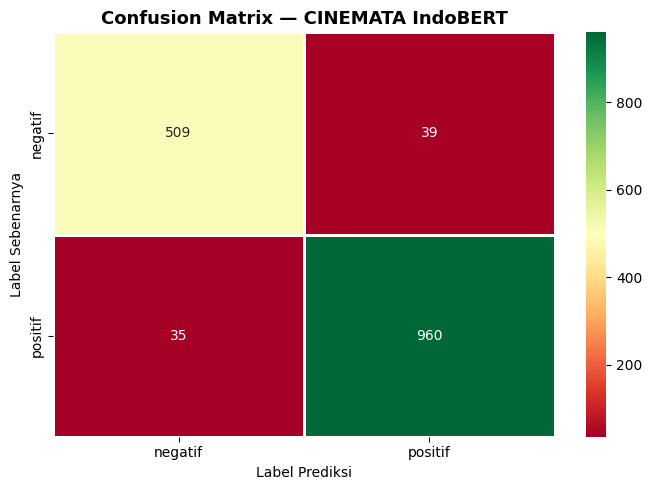


📈 FINAL METRICS
✅ Accuracy      : 95.20%
✅ F1 Weighted   : 95.20%
✅ F1 Macro      : 94.76%


In [39]:
# ============================================================
# 🎬 CINEMATA — Model Evaluation
# ============================================================

print("=" * 60)
print("🧪 EVALUASI MODEL PADA TEST SET")
print("=" * 60)

# ============================================================
# Predict Test Dataset
# ============================================================

print("📥 Melakukan prediksi pada test dataset...\n")

predictions_output = trainer.predict(
    test_dataset
)

y_pred = np.argmax(
    predictions_output.predictions,
    axis=-1
)

y_true = np.array(
    y_test
)

print("✅ Prediksi selesai")

# ============================================================
# Classification Report
# ============================================================

print("\n" + "=" * 60)
print("📊 CLASSIFICATION REPORT")
print("=" * 60)

print(

    classification_report(

        y_true,

        y_pred,

        target_names=[
            "negatif",
            "positif"
        ]
    )
)

# ============================================================
# Confusion Matrix
# ============================================================

print("\n📉 Membuat confusion matrix...")

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="RdYlGn",

    xticklabels=[
        "negatif",
        "positif"
    ],

    yticklabels=[
        "negatif",
        "positif"
    ],

    linewidths=1
)

plt.title(
    "Confusion Matrix — CINEMATA IndoBERT",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Label Sebenarnya"
)

plt.xlabel(
    "Label Prediksi"
)

plt.tight_layout()

plt.show()

# ============================================================
# Final Metrics
# ============================================================

acc = accuracy_score(
    y_true,
    y_pred
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("\n" + "=" * 60)
print("📈 FINAL METRICS")
print("=" * 60)

print(
    f"✅ Accuracy      : "
    f"{acc * 100:.2f}%"
)

print(
    f"✅ F1 Weighted   : "
    f"{f1_weighted * 100:.2f}%"
)

print(
    f"✅ F1 Macro      : "
    f"{f1_macro * 100:.2f}%"
)

print("=" * 60)

## 💾 Cell 13 — Simpan Model

In [40]:
# ============================================================
# 🎬 CINEMATA — Save Model
# ============================================================

print("=" * 60)
print("💾 MENYIMPAN MODEL")
print("=" * 60)

# ============================================================
# Save Model & Tokenizer
# ============================================================

trainer.save_model(
    OUTPUT_DIR
)

tokenizer.save_pretrained(
    OUTPUT_DIR
)

print("✅ Model & tokenizer berhasil disimpan")

# ============================================================
# Save Label Config
# ============================================================

label_config = {

    "id2label": ID2LABEL,

    "label2id": LABEL2ID
}

with open(

    f"{OUTPUT_DIR}/label_config.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        label_config,

        f,

        indent=2,

        ensure_ascii=False
    )

print("✅ label_config.json berhasil dibuat")

# ============================================================
# Save Metrics
# ============================================================

metrics_summary = {

    "accuracy":
        round(float(acc), 4),

    "f1_weighted":
        round(float(f1_weighted), 4),

    "f1_macro":
        round(float(f1_macro), 4),

    "model_name":
        MODEL_NAME,

    "epochs":
        EPOCHS,

    "batch_size":
        BATCH_SIZE,

    "max_length":
        MAX_LENGTH,

    "learning_rate":
        LEARNING_RATE
}

with open(

    f"{OUTPUT_DIR}/metrics.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        metrics_summary,
        f,
        indent=2
    )

print("✅ metrics.json berhasil dibuat")

# ============================================================
# Delete Checkpoints
# ============================================================

import glob

for ckpt in glob.glob(
    f"{OUTPUT_DIR}/checkpoint-*"
):

    shutil.rmtree(ckpt)

print("✅ Checkpoint lama dihapus")

# ============================================================
# Show Saved Files
# ============================================================

print("\n" + "=" * 60)
print("📂 FILE MODEL")
print("=" * 60)

for file in os.listdir(OUTPUT_DIR):

    size = (
        os.path.getsize(
            f"{OUTPUT_DIR}/{file}"
        ) / 1e6
    )

    print(
        f"📄 {file:<35} "
        f"{size:.2f} MB"
    )

print("=" * 60)

💾 MENYIMPAN MODEL


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model & tokenizer berhasil disimpan
✅ label_config.json berhasil dibuat
✅ metrics.json berhasil dibuat
✅ Checkpoint lama dihapus

📂 FILE MODEL
📄 tokenizer.json                      0.71 MB
📄 training_args.bin                   0.01 MB
📄 config.json                         0.00 MB
📄 metrics.json                        0.00 MB
📄 tokenizer_config.json               0.00 MB
📄 model.safetensors                   497.80 MB
📄 label_config.json                   0.00 MB


## 🧪 Cell 14 — Inference / Prediksi Manual

In [43]:
# ============================================================
# 🎬 CINEMATA — Realtime Sentiment Prediction
# ============================================================

def predict_sentiment(

    text,

    model,

    tokenizer,

    device,

    max_length=MAX_LENGTH
):

    # ========================================================
    # Evaluation Mode
    # ========================================================

    model.eval()

    # ========================================================
    # Tokenization
    # ========================================================

    encoding = tokenizer(

        text,

        max_length=max_length,

        padding="max_length",

        truncation=True,

        return_tensors="pt"
    )

    input_ids = encoding[
        "input_ids"
    ].to(device)

    attention_mask = encoding[
        "attention_mask"
    ].to(device)

    # ========================================================
    # Prediction
    # ========================================================

    with torch.no_grad():

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask
        )

        probs = torch.softmax(

            outputs.logits,

            dim=-1

        ).squeeze().cpu().numpy()

    # ========================================================
    # Result
    # ========================================================

    label_id = int(
        np.argmax(probs)
    )

    label = ID2LABEL[
        label_id
    ]

    confidence = float(
        probs[label_id]
    ) * 100

    return {

        "text":
            text,

        "sentiment":
            label,

        "confidence":
            round(confidence, 2),

        "scores": {

            "negatif":
                round(
                    float(probs[0]) * 100,
                    2
                ),

            "positif":
                round(
                    float(probs[1]) * 100,
                    2
                )
        }
    }

print("✅ Realtime prediction function ready")

✅ Realtime prediction function ready


## 📊 Cell 15 — Visualisasi Hasil Prediksi

In [44]:
# ============================================================
# 🎬 CINEMATA — Test Predictions
# ============================================================

test_reviews = [

    # ========================================================
    # POSITIVE
    # ========================================================

    "Film ini sangat bagus dan mengharukan. Saya sangat suka.",

    "Salah satu film terbaik tahun ini. Wajib ditonton.",

    # ========================================================
    # NEGATIVE
    # ========================================================

    "Film ini sangat membosankan dan jelek.",

    "Ceritanya buruk dan terlalu panjang.",

    # ========================================================
    # AMBIGUOUS
    # ========================================================

    "Visualnya bagus tapi ceritanya sangat membosankan.",

    "Film ini sedih banget tapi penyampaian ceritanya luar biasa.",

    "CGI keren namun alurnya jelek dan tidak jelas.",

    "Walaupun endingnya tragis, film ini sangat bagus."
]

print("=" * 60)
print("🎬 HASIL PREDIKSI SENTIMEN")
print("=" * 60)

for review in test_reviews:

    result = predict_sentiment(

        review,

        model,

        tokenizer,

        device
    )

    icon = (
        "😊"
        if result["sentiment"] == "positif"
        else "😤"
    )

    print(
        f"\n{icon} "
        f"[{result['sentiment'].upper()}] "
        f"({result['confidence']}%)"
    )

    print(
        f"📝 Review : "
        f"{review}"
    )

    print(
        f"🟢 Positif : "
        f"{'█' * int(result['scores']['positif']//5):<20} "
        f"{result['scores']['positif']}%"
    )

    print(
        f"🔴 Negatif : "
        f"{'█' * int(result['scores']['negatif']//5):<20} "
        f"{result['scores']['negatif']}%"
    )

print("\n" + "=" * 60)

🎬 HASIL PREDIKSI SENTIMEN

😊 [POSITIF] (99.82%)
📝 Review : Film ini sangat bagus dan mengharukan. Saya sangat suka.
🟢 Positif : ███████████████████  99.82%
🔴 Negatif :                      0.18%

😊 [POSITIF] (99.74%)
📝 Review : Salah satu film terbaik tahun ini. Wajib ditonton.
🟢 Positif : ███████████████████  99.74%
🔴 Negatif :                      0.26%

😤 [NEGATIF] (99.94%)
📝 Review : Film ini sangat membosankan dan jelek.
🟢 Positif :                      0.06%
🔴 Negatif : ███████████████████  99.94%

😤 [NEGATIF] (99.93%)
📝 Review : Ceritanya buruk dan terlalu panjang.
🟢 Positif :                      0.07%
🔴 Negatif : ███████████████████  99.93%

😤 [NEGATIF] (99.94%)
📝 Review : Visualnya bagus tapi ceritanya sangat membosankan.
🟢 Positif :                      0.06%
🔴 Negatif : ███████████████████  99.94%

😊 [POSITIF] (99.66%)
📝 Review : Film ini sedih banget tapi penyampaian ceritanya luar biasa.
🟢 Positif : ███████████████████  99.66%
🔴 Negatif :                      0.34%

😤 [NE

## ☁️ Cell 16 — Download Model (Khusus Google Colab)

In [45]:
# ============================================================
# 🎬 CINEMATA — Export Model ZIP to Google Drive
# ============================================================

import shutil

print("=" * 60)
print("📦 EXPORT MODEL ZIP")
print("=" * 60)

zip_name = "cinemata_model"

# ============================================================
# Create ZIP
# ============================================================

shutil.make_archive(

    zip_name,

    "zip",

    OUTPUT_DIR
)

print(
    f"✅ ZIP berhasil dibuat : "
    f"{zip_name}.zip"
)

# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

# ============================================================
# Save ZIP to Google Drive
# ============================================================

destination = (
    f"/content/drive/MyDrive/"
    f"{zip_name}.zip"
)

shutil.copy(

    f"{zip_name}.zip",

    destination
)

print("\n" + "=" * 60)
print("✅ MODEL BERHASIL DISIMPAN KE GOOGLE DRIVE")
print("=" * 60)

print(
    f"📂 Lokasi File : "
    f"{destination}"
)

print("=" * 60)

📦 EXPORT MODEL ZIP
✅ ZIP berhasil dibuat : cinemata_model.zip
Mounted at /content/drive

✅ MODEL BERHASIL DISIMPAN KE GOOGLE DRIVE
📂 Lokasi File : /content/drive/MyDrive/cinemata_model.zip


## 🔁 Cell 17 — Load Model Tersimpan (Opsional)

In [46]:
# ============================================================
# 🎬 CINEMATA — Load Saved Model
# ============================================================

def load_saved_model(
    model_path,
    device
):

    print("=" * 60)
    print("📦 MEMUAT MODEL CINEMATA")
    print("=" * 60)

    print(f"📂 Model Path :\n{model_path}")

    # ========================================================
    # Load Tokenizer
    # ========================================================

    tokenizer = AutoTokenizer.from_pretrained(
        model_path
    )

    # ========================================================
    # Load Model
    # ========================================================

    model = AutoModelForSequenceClassification.from_pretrained(
        model_path
    )

    # ========================================================
    # Move to Device
    # ========================================================

    model = model.to(device)

    model.eval()

    print("\n✅ Model berhasil dimuat")

    # ========================================================
    # Model Information
    # ========================================================

    total_params = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"🤖 Total Parameter : "
        f"{total_params:,}"
    )

    print(
        f"🖥️ Device           : "
        f"{device}"
    )

    print("=" * 60)

    return model, tokenizer

# ============================================================
# Example Usage
# ============================================================

"""
# Uncomment jika ingin load model tanpa training ulang

model_loaded, tokenizer_loaded = load_saved_model(
    OUTPUT_DIR,
    device
)

result = predict_sentiment(
    "Film ini sangat bagus dan mengharukan",
    model_loaded,
    tokenizer_loaded,
    device
)

print(result)
"""

'\n# Uncomment jika ingin load model tanpa training ulang\n\nmodel_loaded, tokenizer_loaded = load_saved_model(\n    OUTPUT_DIR,\n    device\n)\n\nresult = predict_sentiment(\n    "Film ini sangat bagus dan mengharukan",\n    model_loaded,\n    tokenizer_loaded,\n    device\n)\n\nprint(result)\n'

## 🌐 Cell 18 — Test Koneksi ke Backend


In [47]:
# ============================================================
# 🎬 CINEMATA — Test FastAPI Backend
# ============================================================

import requests

# ============================================================
# Backend URL
# ============================================================

BACKEND_URL = "http://localhost:8000"

# ============================================================
# API Test Function
# ============================================================

def test_api(text):

    try:

        response = requests.post(

            f"{BACKEND_URL}/predict",

            json={
                "text": text
            },

            timeout=10
        )

        # ====================================================
        # Success Response
        # ====================================================

        if response.status_code == 200:

            data = response.json()

            icon = (
                "😊"
                if data["sentiment"] == "positif"
                else "😤"
            )

            print(
                f"{icon} "
                f"{data['sentiment'].upper()} "
                f"({data['confidence']}%)"
            )

            print(
                f"🟢 Positif : "
                f"{data['scores']['positif']}%"
            )

            print(
                f"🔴 Negatif : "
                f"{data['scores']['negatif']}%"
            )

        # ====================================================
        # API Error
        # ====================================================

        else:

            print(
                f"❌ Error {response.status_code}"
            )

            print(response.text)

    # ========================================================
    # Connection Error
    # ========================================================

    except requests.exceptions.ConnectionError:

        print(
            "❌ Backend belum berjalan\n\n"
            "Jalankan:\n"
            "uvicorn app:app --reload"
        )

# ============================================================
# Test Samples
# ============================================================

test_texts = [

    "Film ini luar biasa dan sangat mengharukan!",

    "Ceritanya sangat buruk dan tidak masuk akal.",

    "Walaupun sedih, film ini sangat bagus dan emosional.",

    "Visualnya keren tapi ceritanya membosankan."
]

# ============================================================
# Start Testing
# ============================================================

print("=" * 60)
print("🌐 TEST FASTAPI BACKEND")
print("=" * 60)

for text in test_texts:

    print(f"\n📝 Text:\n{text}\n")

    test_api(text)

    print("-" * 60)

🌐 TEST FASTAPI BACKEND

📝 Text:
Film ini luar biasa dan sangat mengharukan!

❌ Backend belum berjalan

Jalankan:
uvicorn app:app --reload
------------------------------------------------------------

📝 Text:
Ceritanya sangat buruk dan tidak masuk akal.

❌ Backend belum berjalan

Jalankan:
uvicorn app:app --reload
------------------------------------------------------------

📝 Text:
Walaupun sedih, film ini sangat bagus dan emosional.

❌ Backend belum berjalan

Jalankan:
uvicorn app:app --reload
------------------------------------------------------------

📝 Text:
Visualnya keren tapi ceritanya membosankan.

❌ Backend belum berjalan

Jalankan:
uvicorn app:app --reload
------------------------------------------------------------


---

# ✅ PHASE 1 SELESAI — CINEMATA NLP SENTIMENT ANALYSIS

# 🎬 Ringkasan Project

Pada Phase 1, sistem NLP untuk website **CINEMATA** berhasil dibangun menggunakan model transformer **IndoBERT** untuk melakukan analisis sentimen review film bahasa Indonesia secara realtime.

Model mampu melakukan klasifikasi:

- 😊 Positif
- 😤 Negatif

dengan performa evaluasi yang sangat baik menggunakan kombinasi dataset Indonesia, IMDb review, dan custom ambiguous sentiment dataset.

---

# ✅ Tahapan yang Berhasil Dilakukan

## 1️⃣ Dataset Preparation

Dataset yang digunakan:

- SmSA (Indonesian Sentiment Analysis Dataset)
- IMDb Movie Review Dataset
- Custom Ambiguous Sentiment Dataset

Tahapan:

- Load dataset SmSA
- Load IMDb review dataset
- Translasi IMDb review English → Indonesian
- Menambahkan custom ambiguous sentiment dataset
- Menggabungkan seluruh dataset
- Dataset shuffle & balancing
- Dataset visualization

---

## 2️⃣ NLP Preprocessing

Tahapan preprocessing:

- Lowercase normalization
- Remove URL
- Remove HTML tags
- Remove special characters
- Remove numbers
- Remove extra whitespace
- Text cleaning pipeline

Tujuan preprocessing:

- mengurangi noise dataset
- meningkatkan kualitas tokenisasi
- meningkatkan akurasi model
- meningkatkan stabilitas inference

---

## 3️⃣ Fine-Tuning IndoBERT

Model yang digunakan:

```python
indobenchmark/indobert-base-p1
```

Task:

```plaintext
Binary Sentiment Classification
```

Training dilakukan menggunakan:

- PyTorch
- HuggingFace Transformers
- GPU CUDA Tesla T4

---

# 📊 Hasil Evaluasi Model

| Metric | Score |
|---|---|
| Accuracy | 95.20% |
| F1 Weighted | 95.20% |
| F1 Macro | 94.76% |

Model menunjukkan performa sangat baik pada klasifikasi sentimen review film bahasa Indonesia.

---

## 4️⃣ Realtime Sentiment Prediction

Model mampu melakukan:

- realtime prediction
- confidence scoring
- probability scoring
- semantic sentiment analysis
- ambiguous review detection

Contoh output:

```plaintext
😊 POSITIF (99.82%)
😤 NEGATIF (99.94%)
```

---

## 5️⃣ Model Export

Model berhasil diexport menjadi:

- tokenizer
- config
- model weights
- metrics
- label configuration

---

# 📂 Struktur Output Model

```plaintext
cinemata_model/
├── config.json
├── label_config.json
├── metrics.json
├── model.safetensors
├── tokenizer.json
├── tokenizer_config.json
└── training_args.bin
```

---

## 6️⃣ Backend Preparation

Notebook telah disiapkan untuk integrasi:

- FastAPI backend
- React frontend (CINEMATA)
- realtime sentiment API

---

# 🚀 Teknologi yang Digunakan

## Machine Learning & NLP

- Python
- PyTorch
- HuggingFace Transformers
- IndoBERT
- Scikit-Learn

## Data Processing

- Pandas
- NumPy

## Visualization

- Matplotlib
- Seaborn

## Backend & Frontend

- FastAPI
- React JS

---

# 🎯 Output Project

Sistem CINEMATA mampu:

- melakukan analisis sentimen review film secara realtime
- menampilkan confidence prediction
- mendeteksi review ambigu
- melakukan inference melalui REST API
- diintegrasikan ke frontend React

---

# 👥 Kelompok

| Nama | NIM |
|---|---|
| Adi Sani Alviga | 1221601 |
| Vito Arsy Saputra | 1221623 |
| Reza Anwar Sanusi | 3220002 |

---

# 👨‍🏫 Dosen Pengampu

Mochamad Rizki Pratama Suhernawan

---

# 📚 Referensi

## IndoBERT

https://huggingface.co/indobenchmark/indobert-base-p1

---

## HuggingFace Transformers

https://huggingface.co/docs/transformers

---

## IndoNLU Dataset Repository

https://github.com/indobenchmark/indonlu

---

## FastAPI Documentation

https://fastapi.tiangolo.com

---

## React JS Documentation

https://react.dev